# 4. Analysis of external light curves

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [10]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import median_filter
from scipy.stats import binned_statistic
from pathlib import Path

# PlatoSim libraries
import platosim.utilities as ut
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:70% !important; }</style>"))

In [11]:
# Global paths
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
fdir = '/lhome/nicholas/Nextcloud/latex/paperSMBHB/figures'

In [13]:
df = pd.read_csv(path / 'data/ngc6411_asas-sn.csv', comment='#')
df

,asas_sn_id,jd,flux,flux_err,mag,mag_err,limit,fwhm,image_id,camera,quality,phot_filter
0,661432030496,2.456221e+06,24.819002,0.076516,12.972821,0.003351,17.502982,2.91,ba022522,ba,B,V
1,661432030496,2.456229e+06,24.781206,0.125805,12.974475,0.005518,16.963115,2.99,ba028035,ba,B,V
2,661432030496,2.456233e+06,24.805356,0.051516,12.973418,0.002257,17.932493,2.86,ba026859,ba,G,V
3,661432030496,2.456238e+06,24.508090,0.083534,12.986508,0.003705,17.407702,2.87,ba025401,ba,G,V
4,661432030496,2.456338e+06,24.431715,0.059039,12.989897,0.002627,17.784507,2.18,ba040322,ba,G,V
...,...,...,...,...,...,...,...,...,...,...,...,...
2349,661432030496,2.460636e+06,15.717261,0.049352,13.409123,0.003413,17.919373,1.64,bt643464,bt,NaN,g
2350,661432030496,2.460638e+06,15.837674,0.055545,13.400837,0.003812,17.791022,1.53,bt644469,bt,NaN,g
2351,661432030496,2.460639e+06,15.790989,0.056693,13.404042,0.003902,17.768815,1.70,bt644444,bt,NaN,g
2352,661432030496,2.460675e+06,15.918126,0.078865,13.395336,0.005385,17.410435,2.04,bs695605,bs,NaN,g


<IPython.core.display.Javascript object>


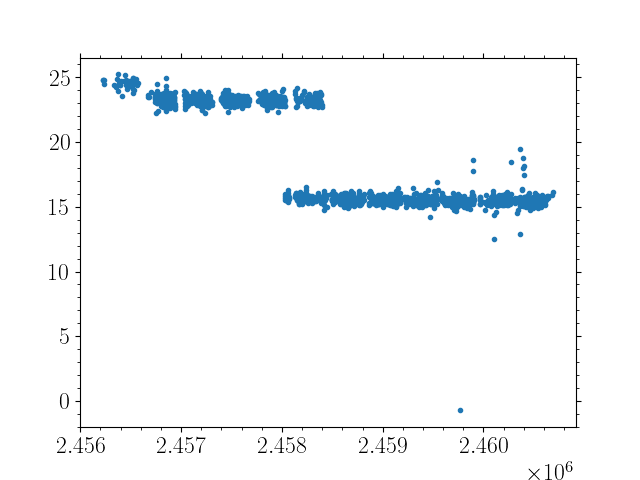

In [14]:
plt.figure()
plt.plot(df.jd, df.flux, '.')